In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

#1) Fazer o PCA e o TSNE para as duas tabelas de dataset. Dataset 1 e Dataset 2 da tabela data_models_rv1

# Para gráficos mais “limpos”
plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["axes.grid"] = True

# ==============================
# 2. Leitura do Excel
# ==============================
# Ajuste aqui o nome do arquivo e a coluna alvo (y)
ARQUIVO_EXCEL = "./data_models_rv1.xlsx"      # <- coloque o nome do seu arquivo
NOME_DA_PAGINA = 'Dataset_1'
NOME_COLUNA_ALVO = "Output: w_exp (mm)"                 # <- coloque aqui o nome da coluna resposta

# Lê a planilha (primeira aba por padrão)
df = pd.read_excel(ARQUIVO_EXCEL, NOME_DA_PAGINA)
df.drop(['Autor'], axis=1, inplace=True)
df

,Diâmetro da armadura (mm),Resistência do aço - fy (MPa),Número de barras em uma camada,Espaçamento entre as barras (mm),Resistência à tração do concreto (MPa),Cobrimento (mm),Distância ao centro de gravidade da armadura (mm),Largura da viga - b (mm),Altura da viga - h (mm),Área de aço tracionada - As (mm2),Taxa de armadura conforme MC2020,Momento fletor - Ms (kNm),Output: w_exp (mm)
0,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,20.800,0.16
1,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,27.300,0.23
2,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,28.200,0.24
3,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,32.600,0.27
4,20.0,500,2,126.0,4.120341,25.0,39.0,216.0,201.0,628.0,0.021300,41.200,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,0.046242,149.268,0.19
337,28.7,276,2,50.6,2.576579,38.0,52.3,152.4,584.2,1290.0,0.046242,168.882,0.22
338,35.8,276,2,36.4,2.547836,38.0,55.9,152.4,584.2,2012.0,0.067478,167.034,0.17
339,35.8,276,2,36.4,2.756373,38.0,55.9,152.4,584.2,2012.0,0.067478,130.788,0.19


Colunas encontradas no dataset:
Index(['Diâmetro da armadura (mm)', 'Resistência do aço - fy (MPa)',
       'Número de barras em uma camada', 'Espaçamento entre as barras (mm)',
       'Resistência à tração do concreto (MPa)', 'Cobrimento (mm)',
       'Distância ao centro de gravidade da armadura  (mm)',
       'Largura da viga - b (mm)', 'Altura da viga - h (mm)',
       'Área de aço tracionada - As (mm2)', 'Taxa de armadura conforme MC2020',
       'Momento fletor - Ms (kNm)', 'Output: w_exp (mm)'],
      dtype='object')

Formato de X: (341, 12)
Formato de y: (341,)

Variância explicada por componente (PCA): [0.31624676 0.19434472]
Variância total explicada (2 PCs): 0.5105914820043366


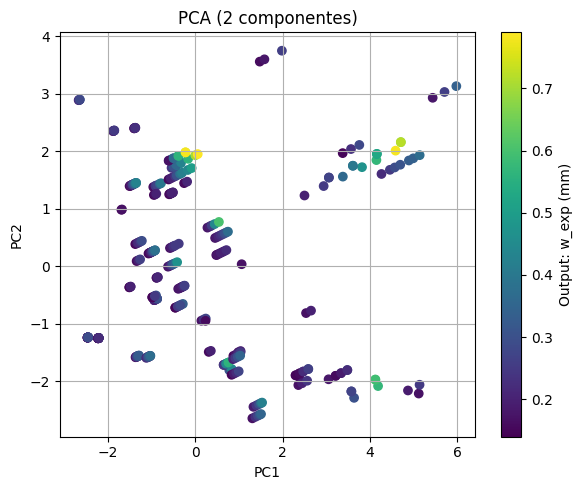

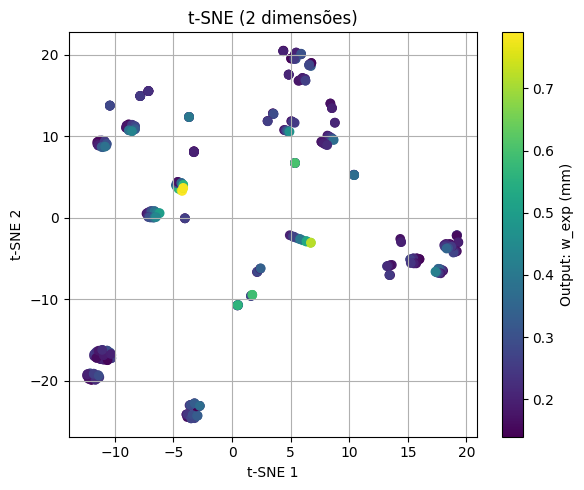


Arquivo 'resultado_pca_tsne.xlsx' gerado com sucesso.


In [7]:
print("Colunas encontradas no dataset:")
print(df.columns)

# Separa X e y
y = df[NOME_COLUNA_ALVO]
X = df.drop(columns=[NOME_COLUNA_ALVO])

print("\nFormato de X:", X.shape)
print("Formato de y:", y.shape)

# ==============================
# 3. Padronização dos dados (média 0, desvio 1)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 4. PCA (redução para 2 componentes)
# ==============================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("\nVariância explicada por componente (PCA):", pca.explained_variance_ratio_)
print("Variância total explicada (2 PCs):", pca.explained_variance_ratio_.sum())

# Plot PCA em 2D
plt.figure()
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA (2 componentes)")
cbar = plt.colorbar(scatter)
cbar.set_label(NOME_COLUNA_ALVO)
plt.tight_layout()
plt.show()

# ==============================
# 5. t-SNE (redução para 2 dimensões)
# ==============================
# t-SNE é mais pesado; para datasets muito grandes, pode demorar.
tsne = TSNE(
    n_components=2,
    perplexity=30,      # ajuste fino se necessário
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

# Plot t-SNE em 2D
plt.figure()
scatter_tsne = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="viridis")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE (2 dimensões)")
cbar_tsne = plt.colorbar(scatter_tsne)
cbar_tsne.set_label(NOME_COLUNA_ALVO)
plt.tight_layout()
plt.show()

# ==============================
# 6. Salvar resultados em Excel (opcional)
# ==============================
# Adiciona as colunas de PCA e t-SNE ao DataFrame original
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]
df["TSNE1"] = X_tsne[:, 0]
df["TSNE2"] = X_tsne[:, 1]

df.to_excel("resultado_pca_tsne.xlsx", index=False)
print("\nArquivo 'resultado_pca_tsne.xlsx' gerado com sucesso.")



=== LOADINGS DO PCA ===
                                                         PC1       PC2
Diâmetro da armadura (mm)                           0.750833 -0.353461
Resistência do aço - fy (MPa)                      -0.460573  0.383243
Número de barras em uma camada                      0.525160  0.659090
Espaçamento entre as barras (mm)                   -0.280762  0.406877
Resistência à tração do concreto (MPa)              0.089163  0.560995
Cobrimento (mm)                                     0.150061 -0.638368
Distância ao centro de gravidade da armadura  (mm)  0.439601 -0.525523
Largura da viga - b (mm)                            0.339112  0.625967
Altura da viga - h (mm)                             0.477440 -0.034791
Área de aço tracionada - As (mm2)                   0.949967  0.119384
Taxa de armadura conforme MC2020                    0.712721 -0.038084
Momento fletor - Ms (kNm)                           0.835795  0.245125

=== FEATURES ORDENADAS POR IMPORTÂNCIA (PCA) ===
  

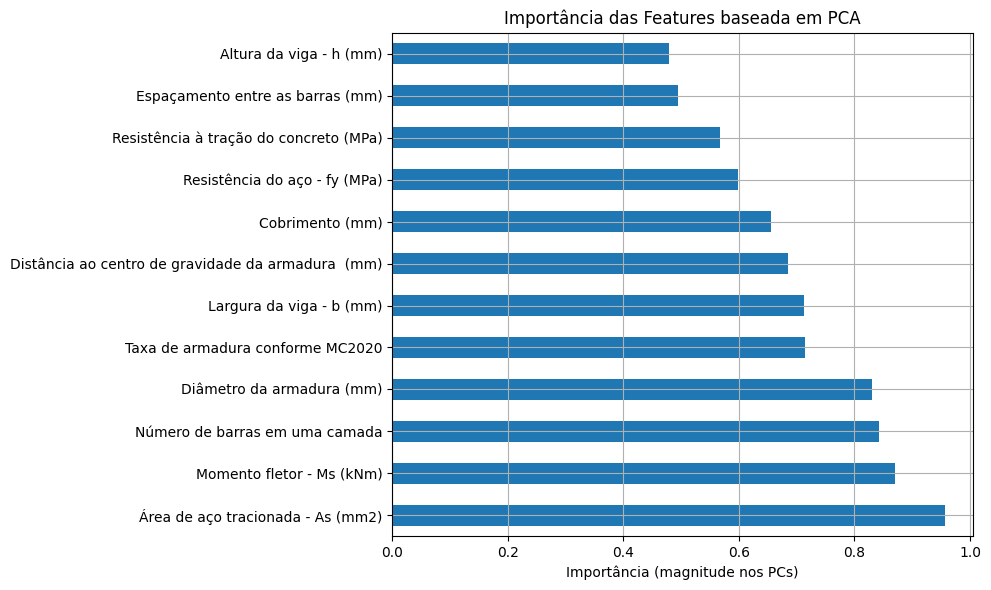

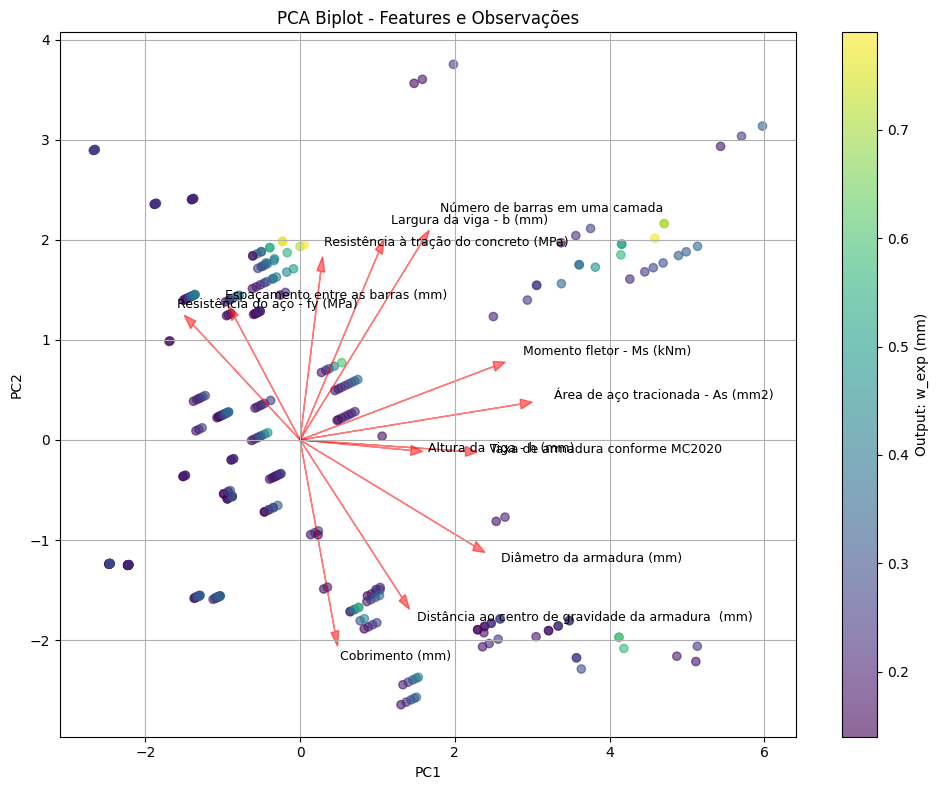

In [8]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

loadings_df = pd.DataFrame(
    loadings,
    columns=['PC1', 'PC2'],
    index=X.columns
)

print("\n=== LOADINGS DO PCA ===")
print(loadings_df)

loadings_df['Importancia_Total'] = np.sqrt(loadings_df['PC1']**2 + loadings_df['PC2']**2)
loadings_df_sorted = loadings_df.sort_values('Importancia_Total', ascending=False)

print("\n=== FEATURES ORDENADAS POR IMPORTÂNCIA (PCA) ===")
print(loadings_df_sorted)

plt.figure(figsize=(10, 6))
loadings_df_sorted['Importancia_Total'].plot(kind='barh')
plt.xlabel('Importância (magnitude nos PCs)')
plt.title('Importância das Features baseada em PCA')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)

scale_factor = 3 
for i, feature in enumerate(X.columns):
    plt.arrow(0, 0, 
              loadings[i, 0] * scale_factor, 
              loadings[i, 1] * scale_factor,
              color='r', alpha=0.5, head_width=0.1)
    plt.text(loadings[i, 0] * scale_factor * 1.15, 
             loadings[i, 1] * scale_factor * 1.15,
             feature, fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Biplot - Features e Observações')
plt.colorbar(label=NOME_COLUNA_ALVO)
plt.grid(True)
plt.tight_layout()
plt.show()


=== CORRELAÇÃO DAS FEATURES COM OS PCs ===
                                                    Corr_PC1  Corr_PC2  \
Área de aço tracionada - As (mm2)                   0.948573  0.119209   
Momento fletor - Ms (kNm)                           0.834568  0.244765   
Diâmetro da armadura (mm)                           0.749731 -0.352942   
Taxa de armadura conforme MC2020                    0.711675 -0.038029   
Número de barras em uma camada                      0.524390  0.658123   
Cobrimento (mm)                                     0.149841 -0.637431   
Largura da viga - b (mm)                            0.338615  0.625048   
Resistência à tração do concreto (MPa)              0.089032  0.560172   
Distância ao centro de gravidade da armadura  (mm)  0.438956 -0.524752   
Altura da viga - h (mm)                             0.476740 -0.034740   
Resistência do aço - fy (MPa)                      -0.459897  0.382680   
Espaçamento entre as barras (mm)                   -0.280350  0.4062

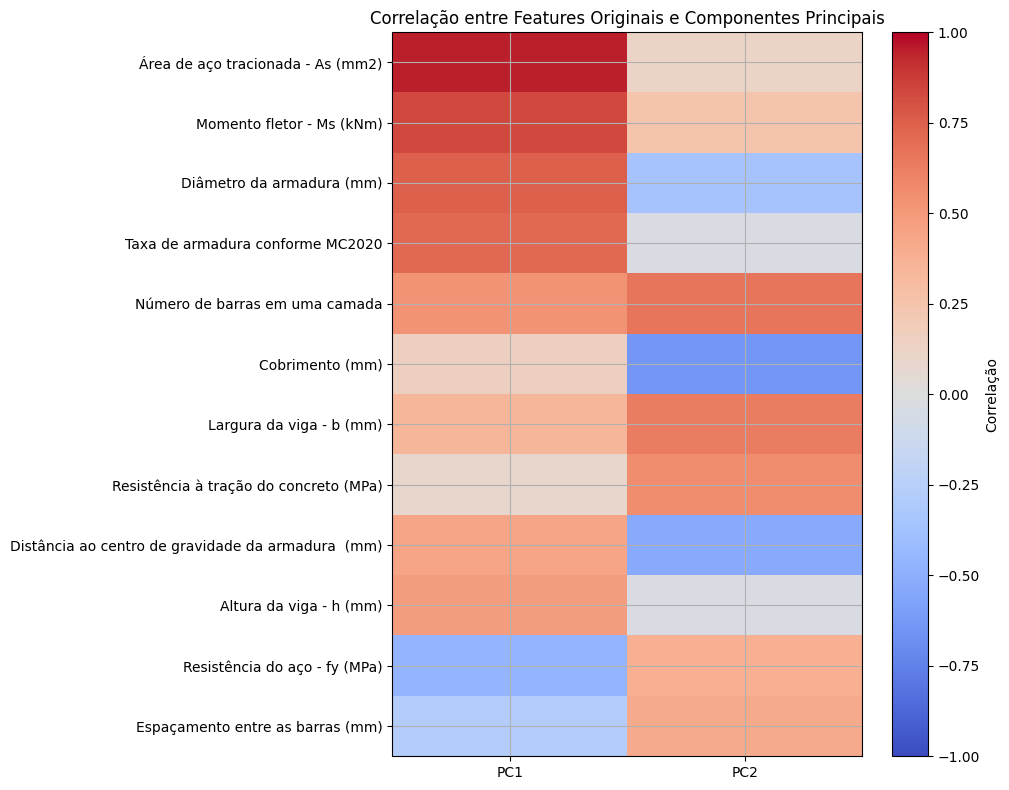

In [9]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

correlacoes = pd.DataFrame(index=X.columns, columns=['Corr_PC1', 'Corr_PC2'])

for col in X.columns:
    correlacoes.loc[col, 'Corr_PC1'] = np.corrcoef(X[col], X_pca[:, 0])[0, 1]
    correlacoes.loc[col, 'Corr_PC2'] = np.corrcoef(X[col], X_pca[:, 1])[0, 1]

correlacoes = correlacoes.astype(float)
correlacoes['Corr_Abs_Max'] = correlacoes.abs().max(axis=1)
correlacoes_sorted = correlacoes.sort_values('Corr_Abs_Max', ascending=False)

print("\n=== CORRELAÇÃO DAS FEATURES COM OS PCs ===")
print(correlacoes_sorted)

plt.figure(figsize=(10, 8))
plt.imshow(correlacoes_sorted[['Corr_PC1', 'Corr_PC2']].values, 
           aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlação')
plt.yticks(range(len(correlacoes_sorted)), correlacoes_sorted.index)
plt.xticks([0, 1], ['PC1', 'PC2'])
plt.title('Correlação entre Features Originais e Componentes Principais')
plt.tight_layout()
plt.show()


=== CORRELAÇÃO DIRETA COM Output: w_exp (mm) ===
Momento fletor - Ms (kNm)                             0.526232
Largura da viga - b (mm)                              0.325865
Altura da viga - h (mm)                               0.299277
Número de barras em uma camada                        0.288969
Área de aço tracionada - As (mm2)                     0.213889
Resistência do aço - fy (MPa)                         0.170688
Distância ao centro de gravidade da armadura  (mm)    0.167820
Diâmetro da armadura (mm)                             0.026775
Espaçamento entre as barras (mm)                      0.016295
Cobrimento (mm)                                      -0.010800
Taxa de armadura conforme MC2020                     -0.024022
Resistência à tração do concreto (MPa)               -0.072067
dtype: float64


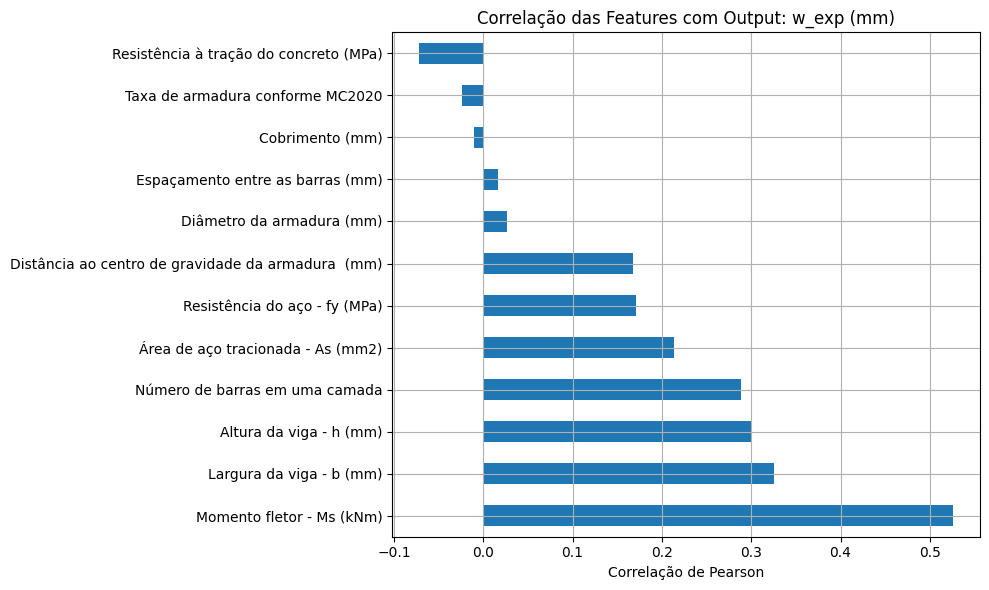

In [10]:
# ==============================
# Correlação direta com o target
# ==============================

correlacao_target = X.corrwith(y).sort_values(ascending=False)

print("\n=== CORRELAÇÃO DIRETA COM", NOME_COLUNA_ALVO, "===")
print(correlacao_target)

plt.figure(figsize=(10, 6))
correlacao_target.plot(kind='barh')
plt.xlabel('Correlação de Pearson')
plt.title(f'Correlação das Features com {NOME_COLUNA_ALVO}')
plt.tight_layout()
plt.show()


=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===
                                              Feature  Importance
11                          Momento fletor - Ms (kNm)    0.432769
8                             Altura da viga - h (mm)    0.135103
2                      Número de barras em uma camada    0.083420
10                   Taxa de armadura conforme MC2020    0.071904
5                                     Cobrimento (mm)    0.067656
4              Resistência à tração do concreto (MPa)    0.053698
3                    Espaçamento entre as barras (mm)    0.049067
6   Distância ao centro de gravidade da armadura  ...    0.034511
9                   Área de aço tracionada - As (mm2)    0.023303
7                            Largura da viga - b (mm)    0.019970
1                       Resistência do aço - fy (MPa)    0.019072
0                           Diâmetro da armadura (mm)    0.009527


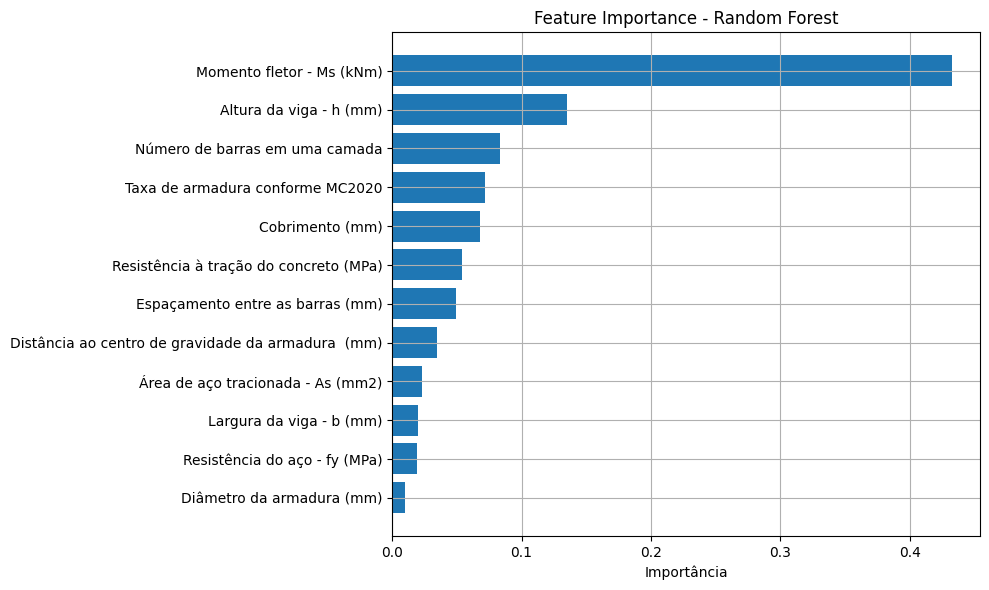

In [11]:
from sklearn.ensemble import RandomForestRegressor

# ==============================
# Feature Importance com Random Forest
# ==============================

rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X, y)

# Importâncias
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n=== IMPORTÂNCIA DAS FEATURES (RANDOM FOREST) ===")
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importância')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()